In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv('loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [9]:
print(df.isnull().sum())

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [11]:
# there are no missing values in the dataset, so we can proceed with the analysis without any imputation.

# cat_cols = df.select_dtypes(include='object').columns
# for col in cat_cols:
#     df.fillna({col:df[col].mode()[0]}, inplace=True)
    
# num_cols = df.select_dtypes(include='number').columns
# for col in num_cols:
#     df.fillna({col:df[col].mean()}, inplace=True)
    

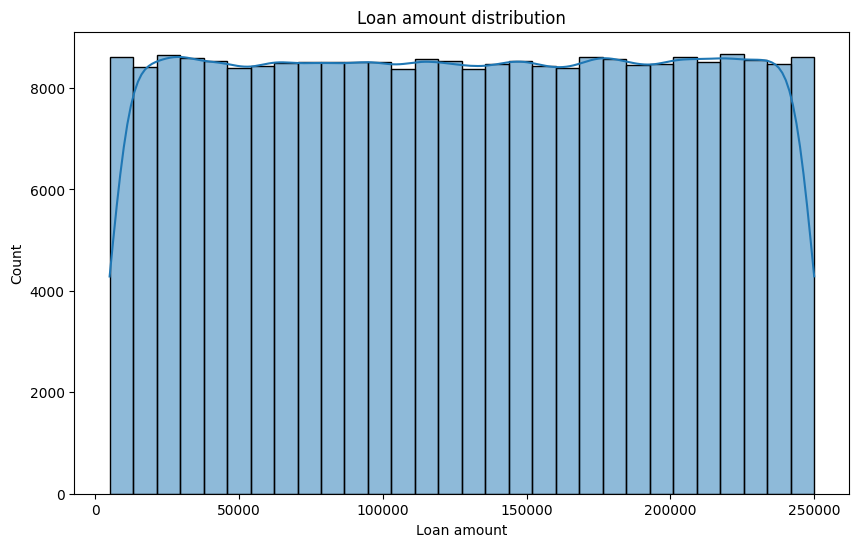

In [16]:
# Loan amount distribution

plt.figure(figsize=(10,6))
sns.histplot(df['LoanAmount'], bins=30, edgecolor='black', kde=True)
plt.title("Loan amount distribution")
plt.xlabel("Loan amount")
plt.ylabel("Count")
plt.show()

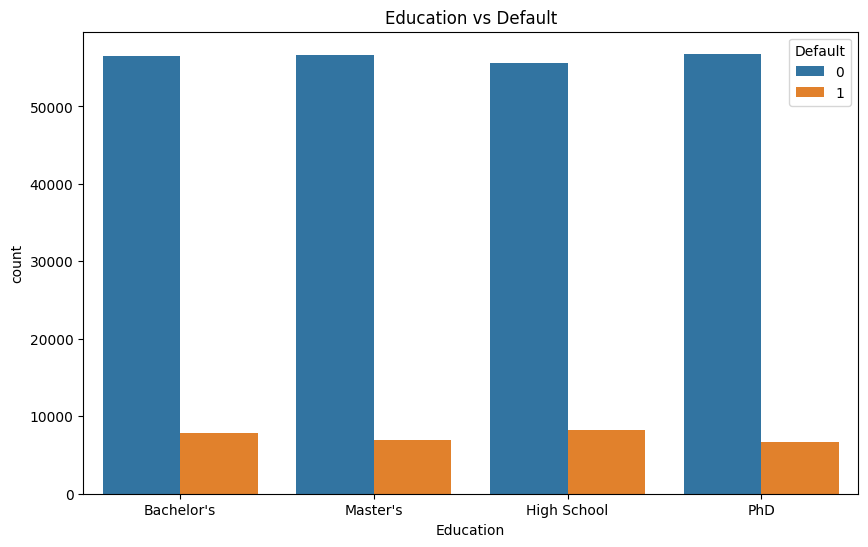

In [21]:
# Education vs Default

plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Education", hue="Default")
plt.title("Education vs Default")
plt.show()



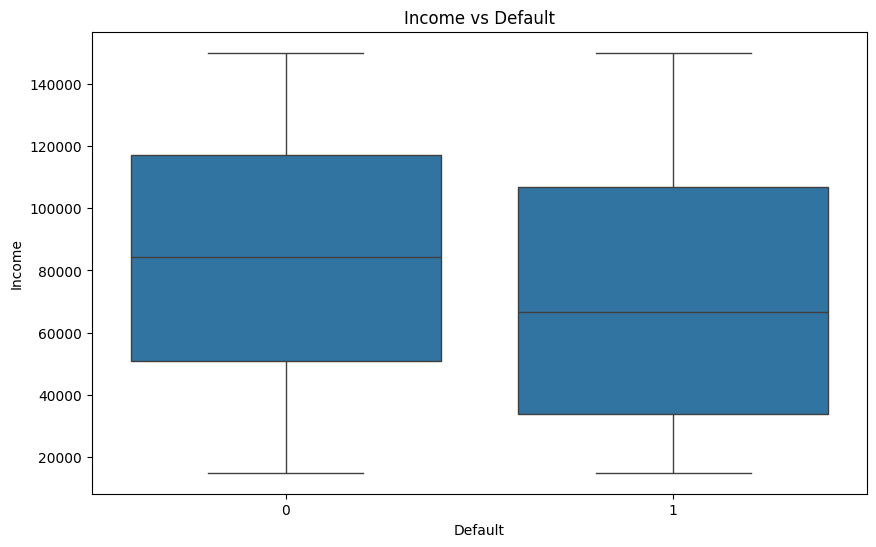

In [22]:
#Income vs Default

plt.figure(figsize=(10,6))
sns.boxplot(data = df,x="Default",y="Income")
plt.title("Income vs Default")
plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder

labeEncoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = labeEncoder.fit_transform(df[col])

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

dummy_Target = df.drop('Default', axis=1)
Target =df['Default']

dummy_Target_train, dummy_Target_test, Target_train, Target_test = train_test_split(dummy_Target, Target, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=900)
model.fit(dummy_Target_train, Target_train)


targt_Prediction = model.predict(dummy_Target_test)

C:\Users\Shahroz butt\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 900 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=900).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.89


Text(0.5, 1.0, 'Confusion Matrix')

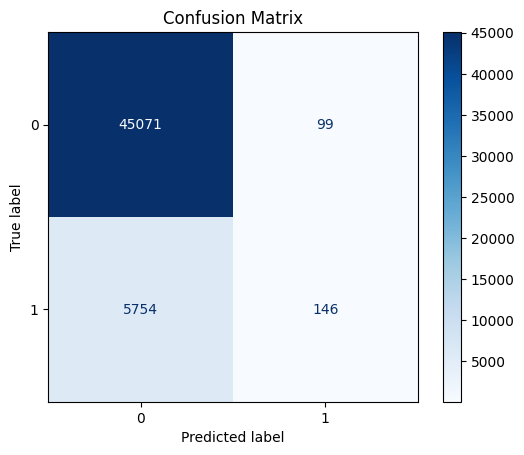

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

accuracy = accuracy_score(Target_test, targt_Prediction)
print(f"Accuracy: {accuracy:.2f}")
cm = confusion_matrix(Target_test, targt_Prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Decision Tree Accuracy: 0.80


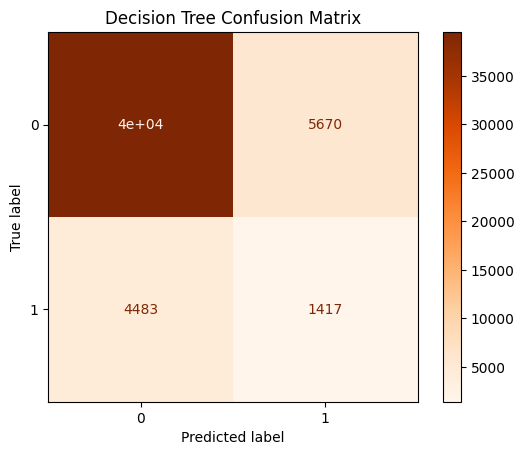

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(dummy_Target_train, Target_train)
dt_Prediction = dt.predict(dummy_Target_test)
accuracy_dt = accuracy_score(Target_test, dt_Prediction)
print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")
cm_dt = confusion_matrix(Target_test, dt_Prediction)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt.classes_)
disp_dt.plot(cmap=plt.cm.Oranges)
plt.title("Decision Tree Confusion Matrix")
plt.show()